# Requirements

In [1]:
import cv2
import numpy as np
import random
import math
from matplotlib import pyplot as plt
from collections import deque

random.seed(42)

# 



Movement commands: fffflflffffrffrfflfaDfbDflff


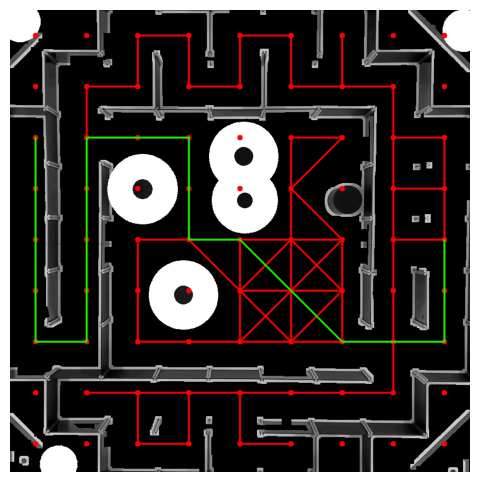

In [ ]:
start_node_idx = (2, 0)
goal_node_idx = (4, 8)

num_grid = 9

line_thickness = 20 # may need changing - 5 is normal for no circles

rows, cols = num_grid, num_grid
cols_b4_cols = num_grid

circle_radius = 45

img = cv2.imread("maze6.jpg")

# Image Processing
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
_, thresh = cv2.threshold(blur, 140, 200, cv2.THRESH_BINARY)
_, contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)
x, y, w, h = cv2.boundingRect(largest_contour)
cropped = img[y:y+h, x:x+w]


# Black and White Conversion
gray_image = cv2.cvtColor(cropped.copy(), cv2.COLOR_BGR2GRAY)

_, mask = cv2.threshold(gray_image, 70, 250, cv2.THRESH_BINARY_INV)

kernel = np.ones((3, 3), np.uint8)
dilated_mask = cv2.dilate(mask, kernel, iterations=5)  # Increase iterations for more thickening

black_white_image = cv2.bitwise_and(gray_image, dilated_mask)


# Detect cylinders in the black and white image
gray = black_white_image.copy()
if len(gray.shape) == 3:
    gray = cv2.cvtColor(gray, cv2.COLOR_BGR2GRAY)

# Find contours in the black and white image
contours_info = cv2.findContours(black_white_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = contours_info[-2]

output_img = black_white_image.copy()  # Keep as single-channel (black and white)
clearance = 5  # Adjust for desired clearance

for cnt in contours:
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    if perimeter == 0:
        continue
    circularity = 4 * np.pi * (area / (perimeter * perimeter))
    # Only consider contours that are sufficiently circular
    if circularity > 0.82 and area > 1:  # area threshold to ignore noise
        (x, y), radius = cv2.minEnclosingCircle(cnt)
        center = (int(x), int(y))
        radius = int(radius)
        cv2.circle(output_img, center, radius + clearance, 255, circle_radius)  # White ring (value 255)


# Find available paths
def is_clear_path(x1, y1, x2, y2):
    line_mask = np.zeros_like(output_img)
    cv2.line(line_mask, (x1, y1), (x2, y2), 255, line_thickness)
    line_pixels = cv2.bitwise_and(output_img, output_img, mask=line_mask)
    return np.all(line_pixels == 0)

img_bgr = cv2.cvtColor(output_img, cv2.COLOR_GRAY2BGR)

height, width = output_img.shape

row_spacing = height // rows
col_spacing = width // cols

nodes = []
for i in range(rows):
    row = []
    for j in range(cols_b4_cols):
        x = j * col_spacing + col_spacing // 2
        y = i * row_spacing + row_spacing // 2
        row.append((x, y))
        cv2.circle(img_bgr, (x, y), 5, (0, 0, 255), -1)
    nodes.append(row)
    
neighbors = {}
for i in range(rows):
    for j in range(cols_b4_cols):
        current = nodes[i][j]
        neighbors[current] = []
        
        # Check right neighbor
        if j < cols_b4_cols - 1 and is_clear_path(nodes[i][j][0], nodes[i][j][1], nodes[i][j + 1][0], nodes[i][j + 1][1]):
            neighbors[current].append(nodes[i][j + 1])
            cv2.line(img_bgr, nodes[i][j], nodes[i][j + 1], (0, 0, 250), 2, lineType=cv2.LINE_AA)

        # Check left neighbor
        if j > 0 and is_clear_path(nodes[i][j][0], nodes[i][j][1], nodes[i][j - 1][0], nodes[i][j - 1][1]):
            neighbors[current].append(nodes[i][j - 1])
            cv2.line(img_bgr, nodes[i][j], nodes[i][j - 1], (0, 0, 250), 2, lineType=cv2.LINE_AA)
        
        # Check bottom neighbor
        if i < rows - 1 and is_clear_path(nodes[i][j][0], nodes[i][j][1], nodes[i + 1][j][0], nodes[i + 1][j][1]):
            neighbors[current].append(nodes[i + 1][j])
            cv2.line(img_bgr, nodes[i][j], nodes[i + 1][j], (0, 0, 250), 2, lineType=cv2.LINE_AA)

        # Check top neighbor
        if i > 0 and is_clear_path(nodes[i][j][0], nodes[i][j][1], nodes[i - 1][j][0], nodes[i - 1][j][1]):
            neighbors[current].append(nodes[i - 1][j])
            cv2.line(img_bgr, nodes[i][j], nodes[i - 1][j], (0, 0, 250), 2, lineType=cv2.LINE_AA)
            
        # Check bottom-right diagonal neighbor
        if i < rows - 1 and j < cols_b4_cols - 1 and is_clear_path(nodes[i][j][0], nodes[i][j][1], nodes[i + 1][j + 1][0], nodes[i + 1][j + 1][1]):
            neighbors[current].append(nodes[i + 1][j + 1])
            cv2.line(img_bgr, nodes[i][j], nodes[i + 1][j + 1], (0, 0, 250), 2, lineType=cv2.LINE_AA)
        
        # Check bottom-left diagonal neighbor
        if i < rows - 1 and j > 0 and is_clear_path(nodes[i][j][0], nodes[i][j][1], nodes[i + 1][j - 1][0], nodes[i + 1][j - 1][1]):
            neighbors[current].append(nodes[i + 1][j - 1])
            cv2.line(img_bgr, nodes[i][j], nodes[i + 1][j - 1], (0, 0, 250), 2, lineType=cv2.LINE_AA)
        
        # Check top-right diagonal neighbor
        if i > 0 and j < cols_b4_cols - 1 and is_clear_path(nodes[i][j][0], nodes[i][j][1], nodes[i - 1][j + 1][0], nodes[i - 1][j + 1][1]):
            neighbors[current].append(nodes[i - 1][j + 1])
            cv2.line(img_bgr, nodes[i][j], nodes[i - 1][j + 1], (0, 0, 250), 2, lineType=cv2.LINE_AA)
        
        # Check top-left diagonal neighbor
        if i > 0 and j > 0 and is_clear_path(nodes[i][j][0], nodes[i][j][1], nodes[i - 1][j - 1][0], nodes[i - 1][j - 1][1]):
            neighbors[current].append(nodes[i - 1][j - 1])
            cv2.line(img_bgr, nodes[i][j], nodes[i - 1][j - 1], (0, 0, 250), 2, lineType=cv2.LINE_AA)


# BFS Pathfinding
start = nodes[start_node_idx[0]][start_node_idx[1]]
goal = nodes[goal_node_idx[0]][goal_node_idx[1]]

def bfs_path(start, goal, neighbors):
    queue = deque([start])
    visited = set([start])
    parent = {start: None}
    
    while queue:
        current = queue.popleft()
        
        if current == goal:
            path = []
            while current is not None:
                path.append(current)
                current = parent[current]
            return path[::-1]  # Return reversed path
        
        # Explore neighbors
        for neighbor in neighbors[current]:
            if neighbor not in visited:
                visited.add(neighbor)
                parent[neighbor] = current
                queue.append(neighbor)
    
    return None  # Return None if no path is found

robot_direction = 'south'  # Assuming the robot starts facing south

def get_direction(from_node, to_node):
    x1, y1 = from_node
    x2, y2 = to_node

    # Analyse the direction based on changes in x and y
    if x2 > x1 and y2 == y1:  # East
        return 'east'
    elif x2 < x1 and y2 == y1:  # West
        return 'west'
    elif x2 == x1 and y2 > y1:  # North
        return 'north'
    elif x2 == x1 and y2 < y1:  # South
        return 'south'
    elif x2 > x1 and y2 > y1:  # Northeast
        return 'northeast'
    elif x2 < x1 and y2 > y1:  # Northwest
        return 'northwest'
    elif x2 > x1 and y2 < y1:  # Southeast
        return 'southeast'
    elif x2 < x1 and y2 < y1:  # Southwest
        return 'southwest'
    else:
        raise ValueError(f"Invalid node pair: {from_node} -> {to_node}")

def direction_to_command(prev_direction, new_direction):
    direction_map = {
        'north': {
            'north': 'f',
            'northeast': 'b',
            'east': 'l',
            'southeast': 'l',
            'south': 'll',
            'southwest': 'r',
            'west': 'r',
            'northwest': 'a'
        },
        'northeast': {
            'north': 'a',  
            'northeast': 'f',
            'east': 'b',
            'southeast': 'l',
            'south': 'l',
            'southwest': 'l',
            'west': 'r',
            'northwest': 'r'
        },
        'east': {
            'north': 'r',
            'northeast': 'a',
            'east': 'f',
            'southeast': 'b',
            'south': 'l',
            'southwest': 'll',
            'west': 'rr',
            'northwest': 'al'
        },
        'southeast': {
            'north': 'al',
            'northeast': 'r',
            'east': 'a',
            'southeast': 'f',
            'south': 'b',
            'southwest': 'l',
            'west': 'll',
            'northwest': 'rr'
        },
        'south': {
            'north': 'rr',
            'northeast': 'ar',
            'east': 'r',
            'southeast': 'a',
            'south': 'f',
            'southwest': 'b',
            'west': 'l',
            'northwest': 'll'
        },
        'southwest': {
            'north': 'll',
            'northeast': 'rr',
            'east': 'ar',
            'southeast': 'r',
            'south': 'a',
            'southwest': 'f',
            'west': 'b',
            'northwest': 'l'
        },
        'west': {
            'north': 'l',
            'northeast': 'll',
            'east': 'rr',
            'southeast': 'al',
            'south': 'r',
            'southwest': 'b',
            'west': 'f',
            'northwest': 'a'
        },
        'northwest': {
            'north': 'b',
            'northeast': 'l',
            'east': 'al',
            'southeast': 'll',
            'south': 'rr',
            'southwest': 'r',
            'west': 'a',
            'northwest': 'f'
        }
    }

    command = direction_map[prev_direction][new_direction]
    
    # Update robot direction after the turn
    if command in ['a', 'b', 'r', 'l']:
        robot_direction = new_direction
    
    return command

def convert_path_to_commands(path):
    commands = ''
    current_direction = get_direction(path[0], path[1])

    for i in range(1, len(path)):
        next_direction = get_direction(path[i - 1], path[i])
        new_cmd = ''

        if current_direction != next_direction:
            new_cmd = direction_to_command(current_direction, next_direction)
            commands += new_cmd
        else:
            new_cmd = ''  # no turn, just forward

        # After each step, add forward/diagonal movement
        if new_cmd in ['a', 'b']:  # diagonal turn
            if cols_b4_cols == 9:
                commands += 'D'
            elif cols_b4_cols == 18:
                commands += 'd'
        else:  # normal forward step
            if cols_b4_cols == 18:
                commands += 's'
            else:
                commands += 'f'

        current_direction = next_direction

    # Post-process: replace "ss" with "f"
    if cols_b4_cols == 18:
        while "ss" in commands:
            commands = commands.replace("ss", "f")

    return commands

path = bfs_path(start, goal, neighbors)

if path:
    for i in range(len(path) - 1):
        cv2.line(img_bgr, path[i], path[i + 1], (0, 255, 0), 2, lineType=cv2.LINE_AA)
else:
    print("No valid path found.")

# Convert the path to movement commands
if path:
    movement_commands = convert_path_to_commands(path)
    print(f"Movement commands: {movement_commands}")
else:
    print("No valid path found.")

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()